# **Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.fixes import parse_version, sp_version
import math
from matplotlib import colors
from matplotlib.colors import LogNorm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.lines as mlines
from scipy.stats import mannwhitneyu
from scipy.stats import linregress
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
solver = "highs" if sp_version >= parse_version("1.6.0") else "interior-point"


# Function to parse size class ranges
def parse_size_class(size_class_str):
    if '-' in size_class_str:
        return list(map(float, size_class_str.replace(' ', '').split('-')))
    else:
        return [float(size_class_str.strip()), float(size_class_str.strip())]

# Function to assign a size class
def assign_size_class(esd_um):
    for i, (low, high) in enumerate(size_class_ranges):
        if low <= esd_um <= high:
            return size_class['size_classes'][i].replace(' ', '')  # Remove extra spaces
    return None


# **Import tracks from APERO**

In [2]:
APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv')
APERO['cruise'] = 'APERO'
APERO['zone'] = 'North Atlantic'
APERO = APERO.drop(columns=['Unnamed: 0'])
APERO

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,48538.074003,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,859557.536536,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9388.330656,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,14976.206705,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,12366.940032,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,86.862360,20230713-042803,APERO_C5_20230713-043248-1-8413,149.314402,859.596554,81.899763,261.384615,62.452042,569.800296,23.870490,0.887168,72.414924,582002.226297,859.596554,24.930501,10.582206,2.904711,36.067138,43.897118,10766.538462,81.923077,23.230769,167.615385,144.384615,217.307692,0.904952,0.410473,0.600251,551,62.452042,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
792,94.602154,20230713-042803,APERO_C5_20230713-043301-1-8717,169.000999,239.397542,53.623205,274.000000,74.398845,569.800296,23.870490,0.887168,12.866225,50557.019943,239.397542,7.284838,2.913288,1.671898,33.266155,60.209407,832.846154,42.307692,24.769231,144.307692,119.538462,19.846154,0.859600,0.539977,0.786790,551,74.398845,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
793,106.876513,20230713-042803,APERO_C5_20230713-043322-1-9208,171.007026,402.057780,91.429246,294.500000,64.130513,569.800296,23.870490,0.887168,21.368446,127511.038493,402.057780,8.258849,5.591207,2.588733,43.980739,48.059479,3149.083333,91.125000,24.500000,176.166667,151.666667,38.583333,0.732405,0.655357,0.888611,551,64.130513,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
794,144.642565,20230713-042803,APERO_C5_20230713-043431-1-11126,84.461913,165.521745,39.600017,362.000000,-60.180652,569.800296,23.870490,0.887168,7.230796,22799.832971,165.521745,4.296724,2.222534,1.708472,14.111826,34.045029,315.222222,37.000000,23.888889,64.555556,40.666667,9.000

# **Import tracks from VLFR**

In [3]:
vlfr = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv')
vlfr['cruise'] = 'vlfr'
vlfr['zone'] = 'Mediterranean Sea'
vlfr

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,167.671521,20230418-142321,vlfr_20230418-142403-1-418,94.296297,114.971982,54.343333,22.000000,-73.375225,660.192273,25.694207,0.588969,4.214214,10511.082352,114.971982,2.756337,1.484728,1.527067,17.261139,35.035069,200.000000,52.900000,34.800000,76.800000,42.000000,3.800000,0.832847,0.733333,1.000000,152,-73.375225,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-84.057856,20230501-231319,vlfr_20230501-231957-1-10371,-140.192296,195.102155,73.021077,376.500000,-56.134440,378.987625,19.467604,0.615935,8.781092,30191.027904,195.102155,4.147502,2.918092,2.116595,33.204497,44.742046,709.375000,68.375000,27.875000,129.875000,102.000000,10.000000,0.682493,0.785764,0.963542,409,-56.134440,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
462,-85.285975,20230501-231319,vlfr_20230501-232003-1-10572,-154.435880,205.712784,68.098055,383.444444,-69.149905,378.987625,19.467604,0.615935,9.418162,33517.908728,205.712784,5.373178,2.573705,1.754223,29.566250,43.793047,718.666667,64.611111,28.333333,123.444444,95.111111,12.000000,0.873998,0.737037,0.879361,409,-69.149905,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
463,-85.481231,20230501-231319,vlfr_20230501-232004-1-10588,-141.559343,191.745555,88.308025,384.555556,-56.078112,378.987625,19.467604,0.615935,8.694304,29664.313902,191.745555,4.250962,2.686470,2.037128,47.433904,54.196583,832.444444,84.055556,27.111111,170.111111,143.000000,9.666667,0.746105,0.803704,0.984127,409,-56.078112,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
464,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,12430.275503,124.717871,2.700440,1.770848,1.725997,29.818883,45.671808,287.000000,59.200000,30.000000,101.400000,71.400000,4.400000,0.642826,0.850000,1.000000,409

# **Import tracks from MBARI**

In [4]:
MBARI = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_selected_tracks_by_interquartile_poly_no_living.csv')
MBARI['cruise'] = 'MBARI'
MBARI['zone'] = 'East Pacific'
MBARI

,pred_poly,r2,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,cruise,zone
0,-302.202743,0.767183,20241122-092156,MBARI_2024_deep_20241122-092222-1-43,-209.716762,319.153410,64.590580,2.250000,92.485980,1090.661571,33.025166,17.295942,9.392982e+04,319.153410,6.436309,4.796762,2.496333,27.896600,44.533920,1799.750000,58.000000,27.000000,118.250000,91.250000,29.000000,0.659835,0.604787,0.899564,331,92.485980,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
1,-245.490231,0.767183,20241122-092156,MBARI_2024_deep_20241122-092335-1-2494,-308.955953,637.109978,88.737119,77.375000,-63.465722,1090.661571,33.025166,35.354446,3.297621e+05,637.109978,12.718429,8.237646,2.757242,40.319565,44.109286,7436.375000,91.562500,23.375000,164.750000,141.375000,92.625000,0.760493,0.593507,0.834002,331,-63.465722,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
2,-172.770546,0.767183,20241122-092156,MBARI_2024_deep_20241122-092522-1-5698,-240.921499,321.356039,89.000179,182.833333,-68.150954,1090.661571,33.025166,16.841288,8.362275e+04,321.356039,7.492178,3.963588,2.239273,47.675998,52.731261,2148.000000,80.583333,26.166667,182.166667,156.000000,26.333333,0.840932,0.681834,0.902910,331,-68.150954,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
3,-146.464486,0.767183,20241122-092156,MBARI_2024_deep_20241122-092603-1-7028,-217.876366,286.954110,72.635846,224.166667,-71.411880,1090.661571,33.025166,16.398479,7.126041e+04,286.954110,8.570610,3.444514,1.848741,39.363747,54.558711,1553.500000,64.916667,25.000000,157.000000,132.000000,27.166667,0.884584,0.564683,0.779750,331,-71.411880,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
4,-132.583725,0.767183,20241122-092156,MBARI_2024_deep_20241122-092626-1-7791,-84.192128,174.511074,65.648571,246.800000,48.391597,1090.661571,33.025166,7.711270,2.728052e+04,174.511074,3.525943,2.685150,2.044897,27.606419,40.661996,607.800000,66.700000,31.200000,105.400000,74.200000,9.600000,0.624614,0.737778,0.941667,331,48.391597,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,78.725582,0.668771,20241123-024802,MBARI_2024_deep_20241123-025632-1-12515,218.307866,406.879633,108.864340,489.333333,139.582284,2327.320811,48.242313,20.156574,1.307180e+05,406.879633,7.705839,5.840463,2.613791,52.568309,48.269216,3825.111111,115.277778,24.222222,198.111111,173.888889,37.888889,0.646066,0.676526,0.929181,287,139.582284,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
432,93.965916,0.668771,20241123-024802,MBARI_2024_deep_20241123-025656-1-13212,227.452282,346.121564,71.687312,511.000000,133.486366,2327.320811,48.242313,21.353133,9.462338e+04,346.121564,10.391992,4.200457,2.078024,34.532351,48.380979,1893.666667,68.333333,24.666667,152.333333,127.666667,37.000000,0.901867,0.484540,0.728088,287,133.486366,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
433,-58.887746,0.649251,20241123-072923,MBARI_2024_deep_20241123-073025-1-1182,55.258119,456.019570,96.353693,33.500000,114.145864,2225.037878,47.170307,24.555333,1.797427e+05,456.019570,9.025341,6.299235,2.660002,45.082890,46.261380,4710.333333,98.166667,24.666667,182.833333,158.166667,52.000000,0.606864,0.650655,0.897017,51,114.145864,-26.368233,20.455338,90.690695,-96.603589,MBARI,East Pacific
434,-18.800687,0.649251,20241123-072923,MBARI_2024_deep_20241123-073129-1-3170,85.750581,1168.870102,85.485560,109.120000,104.551268,2225.037878,47.170307,70.600091,1.170689e+06,1168.870102,20.293223,15.419515,3.510272,31.993327,33.073578,25439.000000,92.840000,23.560000,152.680000,129.120000,282.280000,0.645507,0.559265,0.802992,51,10

# **Combine all datasets**

In [5]:
TZEX_all = pd.concat([APERO, vlfr, MBARI], ignore_index=True)
TZEX_all

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,4.853807e+04,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,8.595575e+05,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9.388331e+03,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,1.497621e+04,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,1.236694e+04,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,78.725582,20241123-024802,MBARI_2024_deep_20241123-025632-1-12515,218.307866,406.879633,108.864340,489.333333,139.582284,2327.320811,48.242313,0.668771,20.156574,1.307180e+05,406.879633,7.705839,5.840463,2.613791,52.568309,48.269216,3825.111111,115.277778,24.222222,198.111111,173.888889,37.888889,0.646066,0.676526,0.929181,287,139.582284,-24.635048,17.825002,81.515077,-88.325124,NaN,MBARI,East Pacific
1694,93.965916,20241123-024802,MBARI_2024_deep_20241123-025656-1-13212,227.452282,346.121564,71.687312,511.000000,133.486366,2327.320811,48.242313,0.668771,21.353133,9.462338e+04,346.121564,10.391992,4.200457,2.078024,34.532351,48.380979,1893.666667,68.333333,24.666667,152.333333,127.666667,37.000000,0.901867,0.484540,0.728088,287,133.486366,-24.635048,17.825002,81.515077,-88.325124,NaN,MBARI,East Pacific
1695,-58.887746,20241123-072923,MBARI_2024_deep_20241123-073025-1-1182,55.258119,456.019570,96.353693,33.500000,114.145864,2225.037878,47.170307,0.649251,24.555333,1.797427e+05,456.019570,9.025341,6.299235,2.660002,45.082890,46.261380,4710.333333,98.166667,24.666667,182.833333,158.166667,52.000000,0.606864,0.650655,0.897017,51,114.145864,-26.368233,20.455338,90.690695,-96.603589,NaN,MBARI,East Pacific
1696,-18.800687,20241123-072923,MBARI_2024_deep_20241123-073129-1-3170,85.750581,1168.870102,85.485560,109.120000,104.551268,2225.037878,47.170307,0.649251,70.600091,1.170689e+06,1168.870102,20.293223,15.419515,3.510272,31.993327,33.073578,25439.000000,92.840000,23.560000,152.680

# **Import UVP6 size classes**

In [6]:
size_class = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/size_classes.csv', delimiter = ';')
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
TZEX_all['size_classes'] = TZEX_all['esd_um'].apply(assign_size_class)
TZEX_all = TZEX_all.sort_values(by='esd_um', ascending=True)
TZEX_all

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes
844,-72.994313,20230421-065822,vlfr_20230421-070038-1-2628,-52.973608,101.000576,65.133333,115.600000,20.020705,161.554939,12.710426,0.867409,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,22.748672,34.038319,195.400000,63.400000,39.200000,92.800000,53.600000,3.000000,0.816497,0.750000,1.000000,378,20.020705,-5.375028,3.038692,15.659273,-17.995609,detritus,vlfr,Mediterranean Sea,80.6-102
56,33.540696,20230611-021733,APERO_C1_20230611-021845-1-1840,-73.891067,101.000576,40.222222,53.500000,-107.431763,1072.634722,32.751103,0.629040,2.643994,8.011938e+03,101.000576,2.696780,1.028456,1.091343,10.369217,25.548753,120.666667,37.000000,29.666667,54.000000,24.333333,3.166667,0.873285,0.750000,0.958333,464,-107.431763,-13.792357,19.978522,70.634841,-64.448676,not-living,APERO,North Atlantic,80.6-102
335,-29.315700,20230619-000510,APERO_C2_20230619-000605-1-675,30.015879,101.000576,68.500000,32.750000,59.331579,286.039562,16.912704,0.823814,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,27.248270,42.666418,205.500000,61.250000,41.000000,103.250000,62.250000,3.000000,0.816497,0.750000,1.000000,327,59.331579,-11.606105,6.515828,33.698728,-38.789005,not-living,APERO,North Atlantic,80.6-102
1209,0.793000,20230429-154426,vlfr_20230429-154846-1-7810,24.525603,101.000576,61.416667,237.500000,23.732603,207.432930,14.402532,0.843136,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,32.586013,53.853369,184.250000,49.500000,31.000000,103.750000,72.750000,3.000000,0.816497,0.750000,1.000000,658,23.732603,-7.168561,4.489143,21.975699,-24.655117,detritus,vlfr,Mediterranean Sea,80.6-102
1085,-53.239504,20230428-163517,vlfr_20230428-163543-1-140,-4.204800,101.000576,47.916667,3.500000,49.034704,287.038936,16.942223,0.888906,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,17.629955,34.558274,143.750000,39.000000,32.250000,72.500000,40.250000,3.000000,0.816497,0.750000,1.000000,783,49.034704,-9.335517,7.704860,33.265426,-34.896083,detritus,vlfr,Mediterranean Sea,80.6-102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,166.407190,20230618-074510,APERO_C2_20230618-074858-1-4483,245.022497,2194.202640,111.094351,193.769231,78.615307,703.570369,26.524901,0.944676,117.280453,4.009599e+06,2194.202640,35.165168,25.684988,3.310478,36.769274,33.273382,79623.000000,117.961538,23.230769,187.153846,163.923077,790.384615,0.670591,0.663635,0.890055,175,78.615307,-16.071405,14.183268,59.565276,-61.453413,not-living,APERO,North Atlantic,2050-2580
114,-183.380236,20230616-234235,APERO_C2_20230616-234324-1-1058,-361.004144,2490.966273,89.460780,31.500000,-177.623908,2507.298879,50.072936,0.620087,290.734499,6.062872e+06,2490.966273,44.124845,32.750980,5.999604,49.449925,56.437075,102099.472222,83.819444,23.833333,234.638889,210.805556,1569.583333,0.655033,0.428360,0.625114,458,-177.623908,-32.808881,28.990423,121.689379,-125.507837,not-living,APERO,North Atlantic,2050-2580
741,78.692618,20230712-141803,APERO_C5_20230712-142447-1-11227,313.654738,3366.873577,121.721052,399.081081,234.962120,1447.442020,38.045263,0.554025,192.964439,8.923245e+06,3366.873577,50.638026,38.078587,3.804609,36.901171,30.335750,175495.702703,132.540541,23.891892,188.081081,164.189189,1660.027027,0.654022,0.720474,0.869799,131,234.962120,-15.223350,13.710858,57.112172,-58.624664,not-living,APERO,North Atlantic,3250-4100
1309,38.354984,20241122-093109,MBARI_2024_deep_20241122-093250-1-2439,246.083727,4545.670752,78.737506,81.090909,207.728743,709.846240,26.642940,0.651337,786.107539,1.841194e+07,4

# Aggregate size classes for DESCENDING tracks 

In [7]:
desc = TZEX_all[TZEX_all['corrected_by_poly'] >= 0]
print(len(desc))
size_classes_count = desc.groupby('size_classes').size().reset_index(name='count')

mean_esd = desc.groupby('size_classes')['esd_um'].mean().reset_index(name='mean_esd')

# Merge the count and mean_esd dataframes
size_classes_count = pd.merge(size_classes_count, mean_esd, on='size_classes')
size_classes_count = size_classes_count.sort_values(by='mean_esd', ascending=True)
size_classes_count

1151


,size_classes,count,mean_esd
16,80.6-102,12,101.000576
0,102-128,225,115.941405
2,128-161,168,141.444754
4,161-203,123,181.353212
6,203-256,103,226.370555
8,256-323,124,287.567907
9,323-406,70,359.873091
11,406-512,70,457.280148
13,512-645,83,579.669139
15,645-813,66,717.821131


In [8]:
# Parse the size classes to make merging easier
def parse_size_class(size_class_str):
    return list(map(float, size_class_str.split('-')))

# Convert size_classes column to parsed ranges
size_classes_count['range'] = size_classes_count['size_classes'].apply(parse_size_class)
size_classes_count

,size_classes,count,mean_esd,range
16,80.6-102,12,101.000576,"[80.6, 102.0]"
0,102-128,225,115.941405,"[102.0, 128.0]"
2,128-161,168,141.444754,"[128.0, 161.0]"
4,161-203,123,181.353212,"[161.0, 203.0]"
6,203-256,103,226.370555,"[203.0, 256.0]"
8,256-323,124,287.567907,"[256.0, 323.0]"
9,323-406,70,359.873091,"[323.0, 406.0]"
11,406-512,70,457.280148,"[406.0, 512.0]"
13,512-645,83,579.669139,"[512.0, 645.0]"
15,645-813,66,717.821131,"[645.0, 813.0]"


In [9]:
desc

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes
844,-72.994313,20230421-065822,vlfr_20230421-070038-1-2628,-52.973608,101.000576,65.133333,115.600000,20.020705,161.554939,12.710426,0.867409,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,22.748672,34.038319,195.400000,63.400000,39.200000,92.800000,53.600000,3.000000,0.816497,0.750000,1.000000,378,20.020705,-5.375028,3.038692,15.659273,-17.995609,detritus,vlfr,Mediterranean Sea,80.6-102
335,-29.315700,20230619-000510,APERO_C2_20230619-000605-1-675,30.015879,101.000576,68.500000,32.750000,59.331579,286.039562,16.912704,0.823814,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,27.248270,42.666418,205.500000,61.250000,41.000000,103.250000,62.250000,3.000000,0.816497,0.750000,1.000000,327,59.331579,-11.606105,6.515828,33.698728,-38.789005,not-living,APERO,North Atlantic,80.6-102
1209,0.793000,20230429-154426,vlfr_20230429-154846-1-7810,24.525603,101.000576,61.416667,237.500000,23.732603,207.432930,14.402532,0.843136,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,32.586013,53.853369,184.250000,49.500000,31.000000,103.750000,72.750000,3.000000,0.816497,0.750000,1.000000,658,23.732603,-7.168561,4.489143,21.975699,-24.655117,detritus,vlfr,Mediterranean Sea,80.6-102
1085,-53.239504,20230428-163517,vlfr_20230428-163543-1-140,-4.204800,101.000576,47.916667,3.500000,49.034704,287.038936,16.942223,0.888906,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,17.629955,34.558274,143.750000,39.000000,32.250000,72.500000,40.250000,3.000000,0.816497,0.750000,1.000000,783,49.034704,-9.335517,7.704860,33.265426,-34.896083,detritus,vlfr,Mediterranean Sea,80.6-102
1199,-21.754431,20230429-154426,vlfr_20230429-154726-1-5355,6.013090,101.000576,84.400000,158.400000,27.767521,207.432930,14.402532,0.843136,2.931371,8.011938e+03,101.000576,2.500718,1.066667,1.243956,37.176415,44.969965,253.200000,84.800000,42.000000,126.400000,84.400000,3.000000,0.853197,0.800000,1.000000,658,27.767521,-7.168561,4.489143,21.975699,-24.655117,detritus,vlfr,Mediterranean Sea,80.6-102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,224.244726,20230704-041233,APERO_C4_20230704-041359-1-1575,351.394882,2138.859708,104.441756,64.000000,127.150156,2604.109701,51.030478,0.635971,146.283381,3.596307e+06,2138.859708,44.608122,21.572777,3.281359,38.028342,36.394851,67748.777778,109.722222,24.666667,180.777778,156.111111,845.000000,0.875143,0.553652,0.767463,141,127.150156,-32.253172,21.234197,101.465252,-112.484226,not-living,APERO,North Atlantic,2050-2580
170,166.407190,20230618-074510,APERO_C2_20230618-074858-1-4483,245.022497,2194.202640,111.094351,193.769231,78.615307,703.570369,26.524901,0.944676,117.280453,4.009599e+06,2194.202640,35.165168,25.684988,3.310478,36.769274,33.273382,79623.000000,117.961538,23.230769,187.153846,163.923077,790.384615,0.670591,0.663635,0.890055,175,78.615307,-16.071405,14.183268,59.565276,-61.453413,not-living,APERO,North Atlantic,2050-2580
741,78.692618,20230712-141803,APERO_C5_20230712-142447-1-11227,313.654738,3366.873577,121.721052,399.081081,234.962120,1447.442020,38.045263,0.554025,192.964439,8.923245e+06,3366.873577,50.638026,38.078587,3.804609,36.901171,30.335750,175495.702703,132.540541,23.891892,188.081081,164.189189,1660.027027,0.654022,0.720474,0.869799,131,234.962120,-15.223350,13.710858,57.112172,-58.624664,not-living,APERO,North Atlantic,3250-4100
1309,38.354984,20241122-093109,MBARI_2024_deep_20241122-093250-1-2439,246.083727,4545.670752,78.737506,81.090909,207.728743,709.846240,26.642940,0.651337,786.107539,1.841194e+07,4545.670752,8

In [10]:
# Initialize variables to store the new merged classes
merged_size_classes = []
current_class = size_classes_count.iloc[0]['range']
current_count = size_classes_count.iloc[0]['count']
current_mean_esd_sum = size_classes_count.iloc[0]['mean_esd'] * size_classes_count.iloc[0]['count']

# Iterate through size classes and merge as necessary
for i in range(1, len(size_classes_count)):
    row = size_classes_count.iloc[i]
    if current_count < 40:
        current_class[1] = row['range'][1]  # Expand the upper limit of the current class
        current_count += row['count']
        current_mean_esd_sum += row['mean_esd'] * row['count']
    else:
        merged_size_classes.append({
            'size_classes': f"{current_class[0]}-{current_class[1]}",
            'count': current_count,
            'mean_esd': current_mean_esd_sum / current_count
        })
        current_class = row['range']
        current_count = row['count']
        current_mean_esd_sum = row['mean_esd'] * row['count']

# Append the last merged class
merged_size_classes.append({
    'size_classes': f"{current_class[0]}-{current_class[1]}",
    'count': current_count,
    'mean_esd': current_mean_esd_sum / current_count
})

# Convert merged size classes to a DataFrame
merged_size_classes_df_desc = pd.DataFrame(merged_size_classes)
merged_size_classes_df_desc['size_classes'] = merged_size_classes_df_desc['size_classes'].apply(lambda x: x.replace('.0', ''))
merged_size_classes_df_desc

,size_classes,count,mean_esd
0,80.6-128,237,115.184908
1,128-161,168,141.444754
2,161-203,123,181.353212
3,203-256,103,226.370555
4,256-323,124,287.567907
5,323-406,70,359.873091
6,406-512,70,457.280148
7,512-645,83,579.669139
8,645-813,66,717.821131
9,813-1020,50,908.950756


In [11]:
# Define the function to assign new merged size classes
def assign_merged_size_class(esd_um):
    for row in merged_size_classes:
        low, high = map(float, row['size_classes'].split('-'))
        if low <= esd_um <= high:
            return row['size_classes']
    return None

# Assign new merged size classes to the original dataframe
desc['new_size_classes'] = desc['esd_um'].apply(assign_merged_size_class)
desc['new_size_classes'] = desc['new_size_classes'].apply(lambda x: x.replace('.0', ''))
desc = desc.sort_values(by='esd_um', ascending=True)
desc['new_size_classes'].unique()

array(['80.6-128', '128-161', '161-203', '203-256', '256-323', '323-406',
       '406-512', '512-645', '645-813', '813-1020', '1020-1630',
       '1630-6500'], dtype=object)

In [12]:
print(len(desc))

1151


In [13]:
size_classes_count = desc.groupby('new_size_classes').size().reset_index(name='count')

mean_esd = desc.groupby('new_size_classes')['esd_um'].mean().reset_index(name='mean_esd')

# Merge the count and mean_esd dataframes
size_classes_count = pd.merge(size_classes_count, mean_esd, on='new_size_classes')
size_classes_count = size_classes_count.sort_values(by='mean_esd', ascending=True)
size_classes_count

,new_size_classes,count,mean_esd
10,80.6-128,237,115.184908
1,128-161,168,141.444754
2,161-203,123,181.353212
4,203-256,103,226.370555
5,256-323,124,287.567907
6,323-406,70,359.873091
7,406-512,70,457.280148
8,512-645,83,579.669139
9,645-813,66,717.821131
11,813-1020,50,908.950756


In [14]:
# Extract min and max mean esd for navier stokes law 
min_esd = size_classes_count['mean_esd'].min()
max_esd = size_classes_count['mean_esd'].max()

# Aggregate size classes fo ASCENDING tracks 

In [15]:
asc = TZEX_all[TZEX_all['corrected_by_poly'] < 0]
print(len(asc))
size_classes_count = asc.groupby('size_classes').size().reset_index(name='count')

mean_esd = asc.groupby('size_classes')['esd_um'].mean().reset_index(name='mean_esd')

# Merge the count and mean_esd dataframes
size_classes_count = pd.merge(size_classes_count, mean_esd, on='size_classes')
size_classes_count = size_classes_count.sort_values(by='mean_esd', ascending=True)
size_classes_count

547


,size_classes,count,mean_esd
12,80.6-102,3,101.000576
0,102-128,112,116.812525
2,128-161,105,142.247166
3,161-203,119,182.353793
5,203-256,80,227.085971
7,256-323,53,286.455983
8,323-406,34,356.604594
9,406-512,17,458.405500
10,512-645,4,588.055900
11,645-813,8,722.888055


In [16]:
# Parse the size classes to make merging easier
def parse_size_class(size_class_str):
    return list(map(float, size_class_str.split('-')))

# Convert size_classes column to parsed ranges
size_classes_count['range'] = size_classes_count['size_classes'].apply(parse_size_class)
size_classes_count

,size_classes,count,mean_esd,range
12,80.6-102,3,101.000576,"[80.6, 102.0]"
0,102-128,112,116.812525,"[102.0, 128.0]"
2,128-161,105,142.247166,"[128.0, 161.0]"
3,161-203,119,182.353793,"[161.0, 203.0]"
5,203-256,80,227.085971,"[203.0, 256.0]"
7,256-323,53,286.455983,"[256.0, 323.0]"
8,323-406,34,356.604594,"[323.0, 406.0]"
9,406-512,17,458.405500,"[406.0, 512.0]"
10,512-645,4,588.055900,"[512.0, 645.0]"
11,645-813,8,722.888055,"[645.0, 813.0]"


In [17]:
# Initialize variables to store the new merged classes
merged_size_classes = []
current_class = size_classes_count.iloc[0]['range']
current_count = size_classes_count.iloc[0]['count']
current_mean_esd_sum = size_classes_count.iloc[0]['mean_esd'] * size_classes_count.iloc[0]['count']

# Iterate through size classes and merge as necessary
for i in range(1, len(size_classes_count)):
    row = size_classes_count.iloc[i]
    if current_count < 40:
        current_class[1] = row['range'][1]  # Expand the upper limit of the current class
        current_count += row['count']
        current_mean_esd_sum += row['mean_esd'] * row['count']
    else:
        merged_size_classes.append({
            'size_classes': f"{current_class[0]}-{current_class[1]}",
            'count': current_count,
            'mean_esd': current_mean_esd_sum / current_count
        })
        current_class = row['range']
        current_count = row['count']
        current_mean_esd_sum = row['mean_esd'] * row['count']

# Append the last merged class
merged_size_classes.append({
    'size_classes': f"{current_class[0]}-{current_class[1]}",
    'count': current_count,
    'mean_esd': current_mean_esd_sum / current_count
})

# Convert merged size classes to a DataFrame
merged_size_classes_df_asc = pd.DataFrame(merged_size_classes)
merged_size_classes_df_asc['size_classes'] = merged_size_classes_df_asc['size_classes'].apply(lambda x: x.replace('.0', ''))
merged_size_classes_df_asc

,size_classes,count,mean_esd
0,80.6-128,115,116.400040
1,128-161,105,142.247166
2,161-203,119,182.353793
3,203-256,80,227.085971
4,256-323,53,286.455983
5,323-512,51,390.538230
6,512-2580,24,1156.259007


In [18]:
# Define the function to assign new merged size classes
def assign_merged_size_class(esd_um):
    for row in merged_size_classes:
        low, high = map(float, row['size_classes'].split('-'))
        if low <= esd_um <= high:
            return row['size_classes']
    return None

# Assign new merged size classes to the original dataframe
asc['new_size_classes'] = asc['esd_um'].apply(assign_merged_size_class)
asc['new_size_classes'] = asc['new_size_classes'].apply(lambda x: x.replace('.0', ''))
asc = asc.sort_values(by='esd_um', ascending=True)
asc['new_size_classes'].unique()

array(['80.6-128', '128-161', '161-203', '203-256', '256-323', '323-512',
       '512-2580'], dtype=object)

In [19]:
print(len(asc))

547


In [20]:
size_classes_count = asc.groupby('new_size_classes').size().reset_index(name='count')

mean_esd = asc.groupby('new_size_classes')['esd_um'].mean().reset_index(name='mean_esd')

# Merge the count and mean_esd dataframes
size_classes_count = pd.merge(size_classes_count, mean_esd, on='new_size_classes')
size_classes_count = size_classes_count.sort_values(by='mean_esd', ascending=True)
size_classes_count

,new_size_classes,count,mean_esd
6,80.6-128,115,116.400040
0,128-161,105,142.247166
1,161-203,119,182.353793
2,203-256,80,227.085971
3,256-323,53,286.455983
4,323-512,51,390.538230
5,512-2580,24,1156.259007


# **Function to plot size vs sinking speed**

In [21]:
def boxplot_desc(ax, x_col, y_col, xlabel, ylabel, subplot_indice, rank, data):
    '''
    x_col, y_col = names of the columns in the dataset
    data = dataset
    '''
    # Define the order of size classes
    size_classes_order = ['80.6-128', '128-161', '161-203', '203-256', '256-323', '323-406',
       '406-512', '512-645', '645-813', '813-1020', '1020-1630',
       '1630-6500']

    # Convert the size_classes column to a categorical type with the specified order
    data[x_col] = pd.Categorical(data[x_col], categories=size_classes_order, ordered=True)

    # Sort the data based on the size_classes
    data = data.sort_values(x_col)

    # Group the data by the qualitative x values
    groups = data.groupby(x_col)

    # Initialize lists to store the overall x and y values for regression
    overall_x = []
    overall_y = []

    # Positions for the box plots
    positions = []
    labels = []
    
    # Dictionary to store upper bounds for text annotation
    upper_bounds = {}
    
    for i, (name, group) in enumerate(groups):
        if len(group) > 0:  # Check if there is data for the current group
            # Extract x and y values for the current group
            y = group[y_col].values
    
            # Calculate IQR to identify outliers
            Q1 = np.percentile(y, 25)
            Q3 = np.percentile(y, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
    
            # Store the upper bound for later use in text annotation
            upper_bounds[i] = upper_bound
            
            # Filter out the outliers for the violin plot
            filtered_y = [val for val in y if lower_bound <= val <= upper_bound]
    
            # Plot box plot for the current group
    
            # Characteristics of the boxplot
            linewidth = 1.5 
            boxprops = dict(linewidth = 3, color = '#10698D') # box
            whiskerprops = dict(linewidth = linewidth, color = '#10698D') # moustache
            flierprops = dict(marker = 'x', alpha = 1, markerfacecolor = '#10698D', markeredgecolor='#10698D') # outliers
            capprops = dict(linewidth = linewidth, color = '#10698D') # horizontal line at the end of the boxplot 
            meanprops = dict(linestyle=(0, (1, 1)), linewidth = 3, color='#10698D', label = 'Mean') # mean
            medianprops = dict(linestyle='-', linewidth = 5, color='#FFC000', label = 'Median') # median
            
            # Plot box plot for the current group
            
            bp = ax.boxplot(y, positions=[i], widths=0.2, showmeans=True, meanline=True, patch_artist=True,
                            boxprops=boxprops, whiskerprops=whiskerprops, showfliers=False,
                            meanprops = meanprops, medianprops=medianprops, capprops=capprops)
            positions.append(i)
            labels.append(name)
            
            for patch in bp['boxes']:
                patch.set_facecolor('#10698D')  # Fill color
            
            # Find the highest cap (whisker) value
            max_cap = bp['whiskers'][1].get_ydata()[1]
    
            # Add the number of observations on top of each cap box plot
            ax.text(i, max_cap + 2, f'n={str(len(filtered_y))}',
                    ha='center', va='bottom', fontsize=35, color='black', fontstyle='italic', fontfamily = 'serif',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05'))
    
            # Plot violin plot for the current group
            vl = ax.violinplot(filtered_y, positions=[i], widths=0.8, showmeans=False, showmedians=False, showextrema = False)
            
            for pc in vl['bodies']:
                pc.set_facecolor('#10698D')
                pc.set_edgecolor('#10698D')
                pc.set_alpha(0.3)

    # Set labels and ticks
    size = 50
    l, w, pad = 15, 8, 15
    ax.tick_params(axis='y', labelsize=size, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size, pad=pad, length=l, width=w)
    ax.set_xlabel(f'{xlabel}', size=size)
    ax.set_ylabel(f'{ylabel}', size=size)


    # Create binned data for table and trendline mapping
    df_med = (
        data
        .groupby(x_col, observed=True)
        .agg(
            D_um=('esd_um', 'mean'),
            w_md=('corrected_by_poly', 'mean')
        )
        .dropna()
    )
    
    # --- PHYSICAL FITTING ON RAW DATA ---
    # We pull from the original 'data' frame to get every individual observation
    D_m_raw = data['esd_um'].values * 1e-6      # m
    w_ms_raw = data['corrected_by_poly'].values / 86400   # m s-1
    
    # Parameters
    rho_sw = 1025
    g = 9.81
    
    # Best Navier-Stokes fit
    slope, intercept, r_value, p_value, stderr = linregress(D_m_raw, w_ms_raw**2)
    K = slope * rho_sw / ((4/3) * g)
    
    print(' ')
    print('Navier-Stokes fitting for sinking particles')
    print(f"Best-fit Δρ / Cd = {K:.3f} kg m⁻3")
    print(f"R² = {r_value**2:.2f}")
    print(f"P-value = {p_value:.2e}")
    print(f"Slope = {slope:.2e}")
    print(f"Intercept = {intercept:.2e}")
    
    # Test some assumptions on drag coefficient add derive delta rho
    Cd_values = [1, 5]
    for Cd in Cd_values:
        delta_rho_kgm3 = K * Cd
        delta_rho_gcm3 = delta_rho_kgm3 * 1e-3
        print(
            f"Cd = {Cd:.2f}  →  Δρ = "
            f"{delta_rho_kgm3:.2f} kg m⁻3  "
            f"({delta_rho_gcm3:.3e} g cm⁻3)"
        )
    
    # Calculate fit line for plotting (using bin centers for x-axis alignment)
    D_m_bins = df_med['D_um'].values * 1e-6
    w_fit_md = np.sqrt(slope * D_m_bins) * 86400
    
    ax.plot(np.arange(len(df_med)), w_fit_md, '--', color='black', linewidth=8, alpha = 0.5, label='NS Raw Fit')    
    
    # Pearson correlation on binned data (for the visual text labels)
    r_coef_pearson, p_val_pearson = pearsonr(df_med['D_um'], df_med['w_md'])
    fit_coeffs = np.polyfit(df_med['D_um'], df_med['w_md'], 1)
    w_fit_line = np.polyval(fit_coeffs, df_med['D_um'].values)

    ax.plot(np.arange(len(df_med)), w_fit_line, '-', color='black', linewidth=8, alpha = 0.5, label='Linear trend')

    # Add the results of the pearson correlation (coeff and p-value)
    text_x, text_y = 0.3, 0.95  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'Pearson coef. = {round(r_coef_pearson, 2)}', color='black', 
         fontsize=size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'

    text_x, text_y = 0.3, 0.9  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'P-value = {p_val_pearson:.2e}', color='black', 
         fontsize=size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'

    # Replace the x-axis numeric positions with group names
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation = 45)
    
    # Create custom legend handles
    mean_line = mlines.Line2D([], [], color='#FFC000', linestyle=(0, (1, 1)), linewidth=3, label='Mean')
    median_line = mlines.Line2D([], [], color='#FFC000', linestyle='-', linewidth=3, label='Median')

    
    ax.grid(True, which="both", ls="--", linewidth=3, zorder = 1, alpha=1)

    # subplot indice
    ax.text(0.96,  0.035, f'{subplot_indice}', color='black', 
         fontsize=65, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)
    
    # Set spine width
    for spine in ax.spines.values():
        spine.set_linewidth(5)
        
    # --- SINKING SPEED COMPARISON TABLE ---
    results_df = pd.DataFrame({
        'Size Class': labels,
        'Mean D (um)': df_med['D_um'].values,
        'Observed Mean (m/d)': df_med['w_md'].values,
        'NS Model Predicted (m/d)': w_fit_md
    })
    print("\nSinking Speed Comparison Table:")
    print(results_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    print("-" * 60)

    return results_df

# **Function to plot size vs rising speed**

In [22]:
def boxplot_asc(ax, x_col, y_col, xlabel, ylabel, subplot_indice, rank, data):
    '''
    x_col, y_col = names of the columns in the dataset
    data = dataset
    '''
    
    # Define the order of size classes
    size_classes_order = ['80.6-128', '128-161', '161-203', '203-256', '256-323', '323-512',
       '512-2580']

    # Convert the size_classes column to a categorical type with the specified order
    data[x_col] = pd.Categorical(data[x_col], categories=size_classes_order, ordered=True)

    # Sort the data based on the size_classes
    data = data.sort_values(x_col)

   
    # Group the data by the qualitative x values
    groups = data.groupby(x_col)

    # Initialize lists to store the overall x and y values for regression
    overall_x = []
    overall_y = []

    # Positions for the box plots
    positions = []
    labels = []
    
    # Dictionary to store upper bounds for text annotation
    upper_bounds = {}
    
    for i, (name, group) in enumerate(groups):
        if len(group) > 0:  # Check if there is data for the current group
            # Extract x and y values for the current group
            y = group[y_col].values
    
            # Calculate IQR to identify outliers
            Q1 = np.percentile(y, 25)
            Q3 = np.percentile(y, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
    
            # Store the upper bound for later use in text annotation
            upper_bounds[i] = upper_bound
            
            # Filter out the outliers for the violin plot
            filtered_y = [val for val in y if lower_bound <= val <= upper_bound]
    
            # Plot box plot for the current group
    
            # Characteristics of the boxplot
            linewidth = 1.5 
            boxprops = dict(linewidth = 3, color = '#10698D') # box
            whiskerprops = dict(linewidth = linewidth, color = '#10698D') # moustache
            flierprops = dict(marker = 'x', alpha = 1, markerfacecolor = '#10698D', markeredgecolor='#10698D') # outliers
            capprops = dict(linewidth = linewidth, color = '#10698D') # horizontal line at the end of the boxplot 
            meanprops = dict(linestyle=(0, (1, 1)), linewidth = 3, color='#10698D', label = 'Mean') # mean
            medianprops = dict(linestyle='-', linewidth = 5, color='#FFC000', label = 'Median') # median
            
            # Plot box plot for the current group
            
            bp = ax.boxplot(y, positions=[i], widths=0.2, showmeans=True, meanline=True, patch_artist=True,
                            boxprops=boxprops, whiskerprops=whiskerprops, showfliers=False,
                            meanprops = meanprops, medianprops=medianprops, capprops=capprops)
            positions.append(i)
            labels.append(name)
            
            for patch in bp['boxes']:
                patch.set_facecolor('#10698D')  # Fill color
            
            # Find the highest cap (whisker) value
            max_cap = bp['whiskers'][0].get_ydata()[1]
    
            # Add the number of observations on top of each cap box plot
            ax.text(i, max_cap - 2, f'n={str(len(filtered_y))}',
                    ha='center', va='bottom', fontsize=35, color='black', fontstyle='italic', fontfamily = 'serif',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05'))
    
            # Plot violin plot for the current group
            vl = ax.violinplot(filtered_y, positions=[i], widths=0.8, showmeans=False, showmedians=False, showextrema = False)
            
            for pc in vl['bodies']:
                pc.set_facecolor('#10698D')
                pc.set_edgecolor('#10698D')
                pc.set_alpha(0.3)

    # Set labels and ticks
    size = 50
    l, w, pad = 15, 8, 15
    ax.tick_params(axis='y', labelsize=size, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size, pad=pad, length=l, width=w)
    ax.set_xlabel(f'{xlabel}', size=size)
    ax.set_ylabel(f'{ylabel}', size=size)

    # Create binned data for table and trendline mapping
    df_med_rise = (
        data
        .groupby(x_col, observed=True)
        .agg(
            D_um=('esd_um', 'mean'),
            w_md=('corrected_by_poly', 'mean')
        )
        .dropna()
    )
    
    # --- PHYSICAL FITTING ON RAW DATA ---
    # We pull from the original 'data' frame to get every individual observation
    D_m_raw_rise = data['esd_um'].values * 1e-6      # m
    w_ms_raw_rise = data['corrected_by_poly'].values / 86400   # m s-1
    
    # Parameters
    rho_sw = 1025
    g = 9.81
    
    # Best Navier-Stokes fit
    slope_rise, intercept_rise, r_value_rise, p_value_rise, stderr_rise = linregress(D_m_raw_rise, np.abs(w_ms_raw_rise)**2)
    K_rise = slope_rise * rho_sw / ((4/3) * g)
    
    print(' ')
    print('Navier-Stokes fitting for rising particles')
    print(f"Best-fit Δρ / Cd = {-K_rise:.3f} kg m⁻3")
    print(f"R² = {r_value_rise**2:.2f}")
    print(f"P-value = {p_value_rise:.2e}")
    print(f"Slope = {slope_rise:.2e}")
    print(f"Intercept = {intercept_rise:.2e}")
    
    # Test some assumptions on drag coefficient add derive delta rho
    Cd_values = [1, 5]
    for Cd in Cd_values:
        delta_rho_kgm3 = -K_rise * Cd
        delta_rho_gcm3 = delta_rho_kgm3 * 1e-3
        print(
            f"Cd = {Cd:.2f}  →  Δρ = "
            f"{delta_rho_kgm3:.2f} kg m⁻3  "
            f"({delta_rho_gcm3:.3e} g cm⁻3)"
        )
    
    # Calculate fit line for plotting (using bin centers for x-axis alignment)
    D_m_bins_rise = df_med_rise['D_um'].values * 1e-6
    w_fit_md_rise = -np.sqrt(slope_rise * D_m_bins_rise) * 86400
    
    ax.plot(np.arange(len(df_med_rise)), w_fit_md_rise, '--', color='black', linewidth=8, alpha = 0.5, label='NS Raw Fit')    
    
    # Pearson correlation on binned data (for the visual text labels)
    r_coef_pearson_rise, p_val_pearson_rise = pearsonr(df_med_rise['D_um'], df_med_rise['w_md'])
    fit_coeffs_rise = np.polyfit(df_med_rise['D_um'], df_med_rise['w_md'], 1)
    w_fit_line_rise = np.polyval(fit_coeffs_rise, df_med_rise['D_um'].values)

    ax.plot(np.arange(len(df_med_rise)), w_fit_line_rise, '-', color='black', linewidth=8, alpha = 0.5, label='Linear trend')

    # Add the results of the pearson correlation (coeff and p-value)
    text_x, text_y = 0.3, 0.95  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'Pearson coef. = {round(r_coef_pearson_rise, 2)}', color='black', 
         fontsize=size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'

    text_x, text_y = 0.3, 0.9  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'P-value = {p_val_pearson_rise:.2e}', color='black', 
         fontsize=size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'

    # Replace the x-axis numeric positions with group names
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation = 45)
    
    # Create custom legend handles
    mean_line = mlines.Line2D([], [], color='#FFC000', linestyle=(0, (1, 1)), linewidth=3, label='Mean')
    median_line = mlines.Line2D([], [], color='#FFC000', linestyle='-', linewidth=3, label='Median')

    
    ax.grid(True, which="both", ls="--", linewidth=3, zorder = 1, alpha=1)

    # subplot indice
    ax.text(0.96,  0.035, f'{subplot_indice}', color='black', 
         fontsize=65, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)
    
    ax.invert_yaxis() 
    # Set spine width
    for spine in ax.spines.values():
        spine.set_linewidth(5)
        
    # --- SINKING SPEED COMPARISON TABLE ---
    results_df = pd.DataFrame({
        'Size Class': labels,
        'Mean D (um)': df_med_rise['D_um'].values,
        'Observed Mean (m/d)': df_med_rise['w_md'].values,
        'NS Model Predicted (m/d)': w_fit_md_rise
    })
    print("\nRising Speed Comparison Table:")
    print(results_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    print("-" * 60)

    return results_df

# **Import results from Multi-Otsu thresholding**

In [23]:
multi_otu_thresh =pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Multi_Otsu_Thresholding/APERO_VLFR_MBARI_selected_tracks_poly_with_multi_threshold_meangrey.csv')
print(multi_otu_thresh)

                                    track_id       esd_um  corrected_by_poly  \
0            APERO_C1_20230611-002829-1-1435  1035.906803          78.591289   
1           APERO_C1_20230611-022354-1-13404   504.891837         121.783572   
2             APERO_C2_20230616-234310-1-430   947.926007        -299.721854   
3            APERO_C2_20230616-234324-1-1058  2564.254579        -177.623908   
4            APERO_C2_20230616-234458-1-4467   656.053843        -180.577169   
..                                       ...          ...                ...   
382  MBARI_2024_deep_20241123-025613-1-11947   555.962259         140.362948   
383  MBARI_2024_deep_20241123-025618-1-12057   788.071914         161.495148   
384   MBARI_2024_deep_20241123-073025-1-1182   528.323107         114.145864   
385   MBARI_2024_deep_20241123-073129-1-3170  1200.585174         104.551268   
386   MBARI_2024_deep_20241123-073249-1-5338   577.719541        -115.541890   

       area_low   area_high  low_grey_p

In [24]:
print(multi_otu_thresh['total_area'].min())

22.0


# **Function to create a boxplot**

In [25]:
def boxplot(x_col, y_col, data, xlabel, ylabel, subplot_indice, bracket_width, bracket_length, zone, ax):
    '''
    x_col, y_col = names of the columns in the dataset
    data = dataset
    '''

    # Define the order of size classes
    orientation_order = ['desc', 'asc']

    # Convert the depth column to a categorical type with the specified order
    data[x_col] = pd.Categorical(data[x_col], categories=orientation_order, ordered=True)

    # Sort the data based on the size_classes
    data = data.sort_values(x_col)

    # Group the data by the qualitative x values
    groups = data.groupby(x_col)
    
    # Separate the data into two groups based on orientation for statistical test
    asc_areas = data[data[x_col] == 'asc'][y_col]
    desc_areas = data[data[x_col] == 'desc'][y_col]

    # Perform Mann-Whitney U Test
    stat, p_value = mannwhitneyu(asc_areas, desc_areas, alternative='greater')
    
    # Initialize lists to store the overall x and y values for regression
    overall_x = []
    overall_y = []

    # Positions for the box plots
    positions = []
    labels = []
    
    # Dictionary to store upper bounds for text annotation
    upper_bounds = {}
    
    for i, (name, group) in enumerate(groups):
        if len(group) > 0:  # Check if there is data for the current group
            # Extract x and y values for the current group
            y = group[y_col].values
            
            
            # Calculate IQR to identify outliers
            Q1 = np.percentile(y, 25)
            Q3 = np.percentile(y, 75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
    
            # Store the upper bound for later use in text annotation
            upper_bounds[i] = upper_bound
            
            # Filter out the outliers for the violin plot
            filtered_y = [val for val in y if lower_bound <= val <= upper_bound]
    
            # Plot box plot for the current group
    
            # Characteristics of the boxplot
            linewidth = 1.5 
            boxprops = dict(linewidth = 3, color = '#10698D') # box
            whiskerprops = dict(linewidth = linewidth, color = '#10698D') # moustache
            flierprops = dict(marker = 'x', alpha = 1, markerfacecolor = '#10698D', markeredgecolor='#10698D') # outliers
            capprops = dict(linewidth = linewidth, color = '#10698D') # horizontal line at the end of the boxplot 
            meanprops = dict(linestyle=(0, (1, 1)), linewidth = 3, color='#10698D', label = 'Mean') # mean
            medianprops = dict(linestyle='-', linewidth = 5, color='#FFC000', label = 'Median') # median
            
            # Plot box plot for the current group
            
            bp = ax.boxplot(y, positions=[i], widths=0.2, showmeans=True, meanline=True, patch_artist=True,
                            boxprops=boxprops, whiskerprops=whiskerprops, showfliers=False,
                            meanprops = meanprops, medianprops=medianprops, capprops=capprops)
            positions.append(i)
            labels.append(name)
            
            for patch in bp['boxes']:
                patch.set_facecolor('#10698D')  # Fill color
            
            # Find the highest cap (whisker) value
            max_cap = bp['whiskers'][1].get_ydata()[1]
    
            # Add the number of observations on top of each cap box plot
            ax.text(i, max_cap + 0.03, f'n = {str(len(filtered_y))}',
                    ha='center', va='bottom', fontsize=35, color='black', fontstyle='italic', fontfamily = 'serif',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05'))
    
            # Plot violin plot for the current group
            vl = ax.violinplot(filtered_y, positions=[i], widths=0.8, showmeans=False, showmedians=False, showextrema = False)
            
            for pc in vl['bodies']:
                pc.set_facecolor('#10698D')
                pc.set_edgecolor('#10698D')
                pc.set_alpha(0.3)


    # limit 
    ax.set_ylim(0.2, 2.2)
    
    # Add the results of the pearson correlation (coeff and p-value)
    '''
    text_x, text_y = 0.13, 0.95  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'Pearson correlation coef = {round(corr, 2)}', color='black', 
         fontsize=17, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes) # fontweight = 'bold'

    text_x, text_y = 0.13, 0.925  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'P-value = {p_value:.2e}', color='black', 
         fontsize=17, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes) # fontweight = 'bold'
    '''
    # Replace the x-axis numeric positions with group names
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    # Labels and title for the first subplot
    size = 50
    l, w, pad = 15, 8, 15
    ax.tick_params(axis='y', labelsize=size, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size, pad=pad, length=l, width=w)
    ax.set_xlabel(f'{xlabel}', size=size)
    ax.set_ylabel(f'{ylabel}', size=size)

    # Brace for statistical test
    #f'$P_{{\\mathrm{{MannWhitney}}}}  ≈  {p_value:.2e}$'
    ax.annotate('', xy=(0.5, 0.84), xytext=(0.5, 0.86), xycoords='axes fraction', 
            fontsize=30, ha='center', va='bottom',
            #bbox=dict(boxstyle='round', fc='white', color='k', pad = 1, lw = 2),
            arrowprops=dict(arrowstyle=f'-[, widthB={bracket_width}, lengthB={bracket_length}', lw=5, color='k'))
    
    # Add the pvalue
    text_x, text_y = 0.5, 0.9  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'$P_{{\\mathrm{{MannWhitney}}}}  ≈  {p_value:.2e}$', color='black', 
         fontsize=50, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'        
    
    # Add the zone
    text_x, text_y = 0.5, 0.97  # Adjust coordinates as needed
    ax.text(text_x,  text_y, f'{zone}', color='black', 
         fontsize=50, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.05')) # fontweight = 'bold'    
    
    # Create custom legend handles
    mean_line = mlines.Line2D([], [], color='#FFC000', linestyle=(0, (1, 1)), linewidth=3, label='Mean')
    median_line = mlines.Line2D([], [], color='#FFC000', linestyle='-', linewidth=3, label='Median')

    ax.grid(True, which="both", ls="--", linewidth=3, zorder = 1, alpha=1)
    
    # subplot indice
    ax.text(0.96,  0.035, f'{subplot_indice}', color='black', 
         fontsize=65, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)
    
    # Set the line width for all spines (top, bottom, left, right)
    for spine in ax.spines.values():
        spine.set_linewidth(5)

In [26]:
desc[['esd_um', 'corrected_by_poly']].head(3)

,esd_um,corrected_by_poly
335,101.000576,59.331579
844,101.000576,20.020705
841,101.000576,16.260786


In [27]:
desc.columns

Index(['pred_poly', 'sequence', 'track_id', 'vertical_speed', 'size_um',
       'meangrey', 'time', 'error', 'mse', 'rmse', 'r2', 'perim_px', 'area_um',
       'esd_um', 'major_px', 'minor_px', 'perimmajor', 'stdgrey', 'cvgrey',
       'intgrey', 'mediangrey', 'mingrey', 'maxgrey', 'rangegrey',
       'area_convex', 'eccentricity', 'extent', 'solidity', 'track_count',
       'corrected_by_poly', 'Q1', 'Q3', 'upper_bound', 'lower_bound',
       'object_annotation_category', 'cruise', 'zone', 'size_classes',
       'new_size_classes'],
      dtype='object')

In [28]:
asc[['esd_um', 'corrected_by_poly']].head(3)

,esd_um,corrected_by_poly
176,101.000576,-58.868245
180,101.000576,-68.557102
56,101.000576,-107.431763


# **Create the figure** 

/tmp/ipykernel_326874/3415180935.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(x_col)
/tmp/ipykernel_326874/2118352604.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(x_col)
/tmp/ipykernel_326874/613464483.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(x_col)


 
Navier-Stokes fitting for sinking particles
Best-fit Δρ / Cd = 0.157 kg m⁻3
R² = 0.17
P-value = 2.98e-48
Slope = 2.00e-03
Intercept = 5.83e-07
Cd = 1.00  →  Δρ = 0.16 kg m⁻3  (1.566e-04 g cm⁻3)
Cd = 5.00  →  Δρ = 0.78 kg m⁻3  (7.830e-04 g cm⁻3)

Sinking Speed Comparison Table:
Size Class  Mean D (um)  Observed Mean (m/d)  NS Model Predicted (m/d)
  80.6-128       115.18                56.45                     41.45
   128-161       141.44                63.76                     45.94
   161-203       181.35                74.15                     52.01
   203-256       226.37                81.44                     58.11
   256-323       287.57                97.75                     65.50
   323-406       359.87                91.71                     73.27
   406-512       457.28               104.59                     82.59
   512-645       579.67                93.89                     92.99
   645-813       717.82               100.59                    103.48
  813-1020

/tmp/ipykernel_326874/613464483.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(x_col)


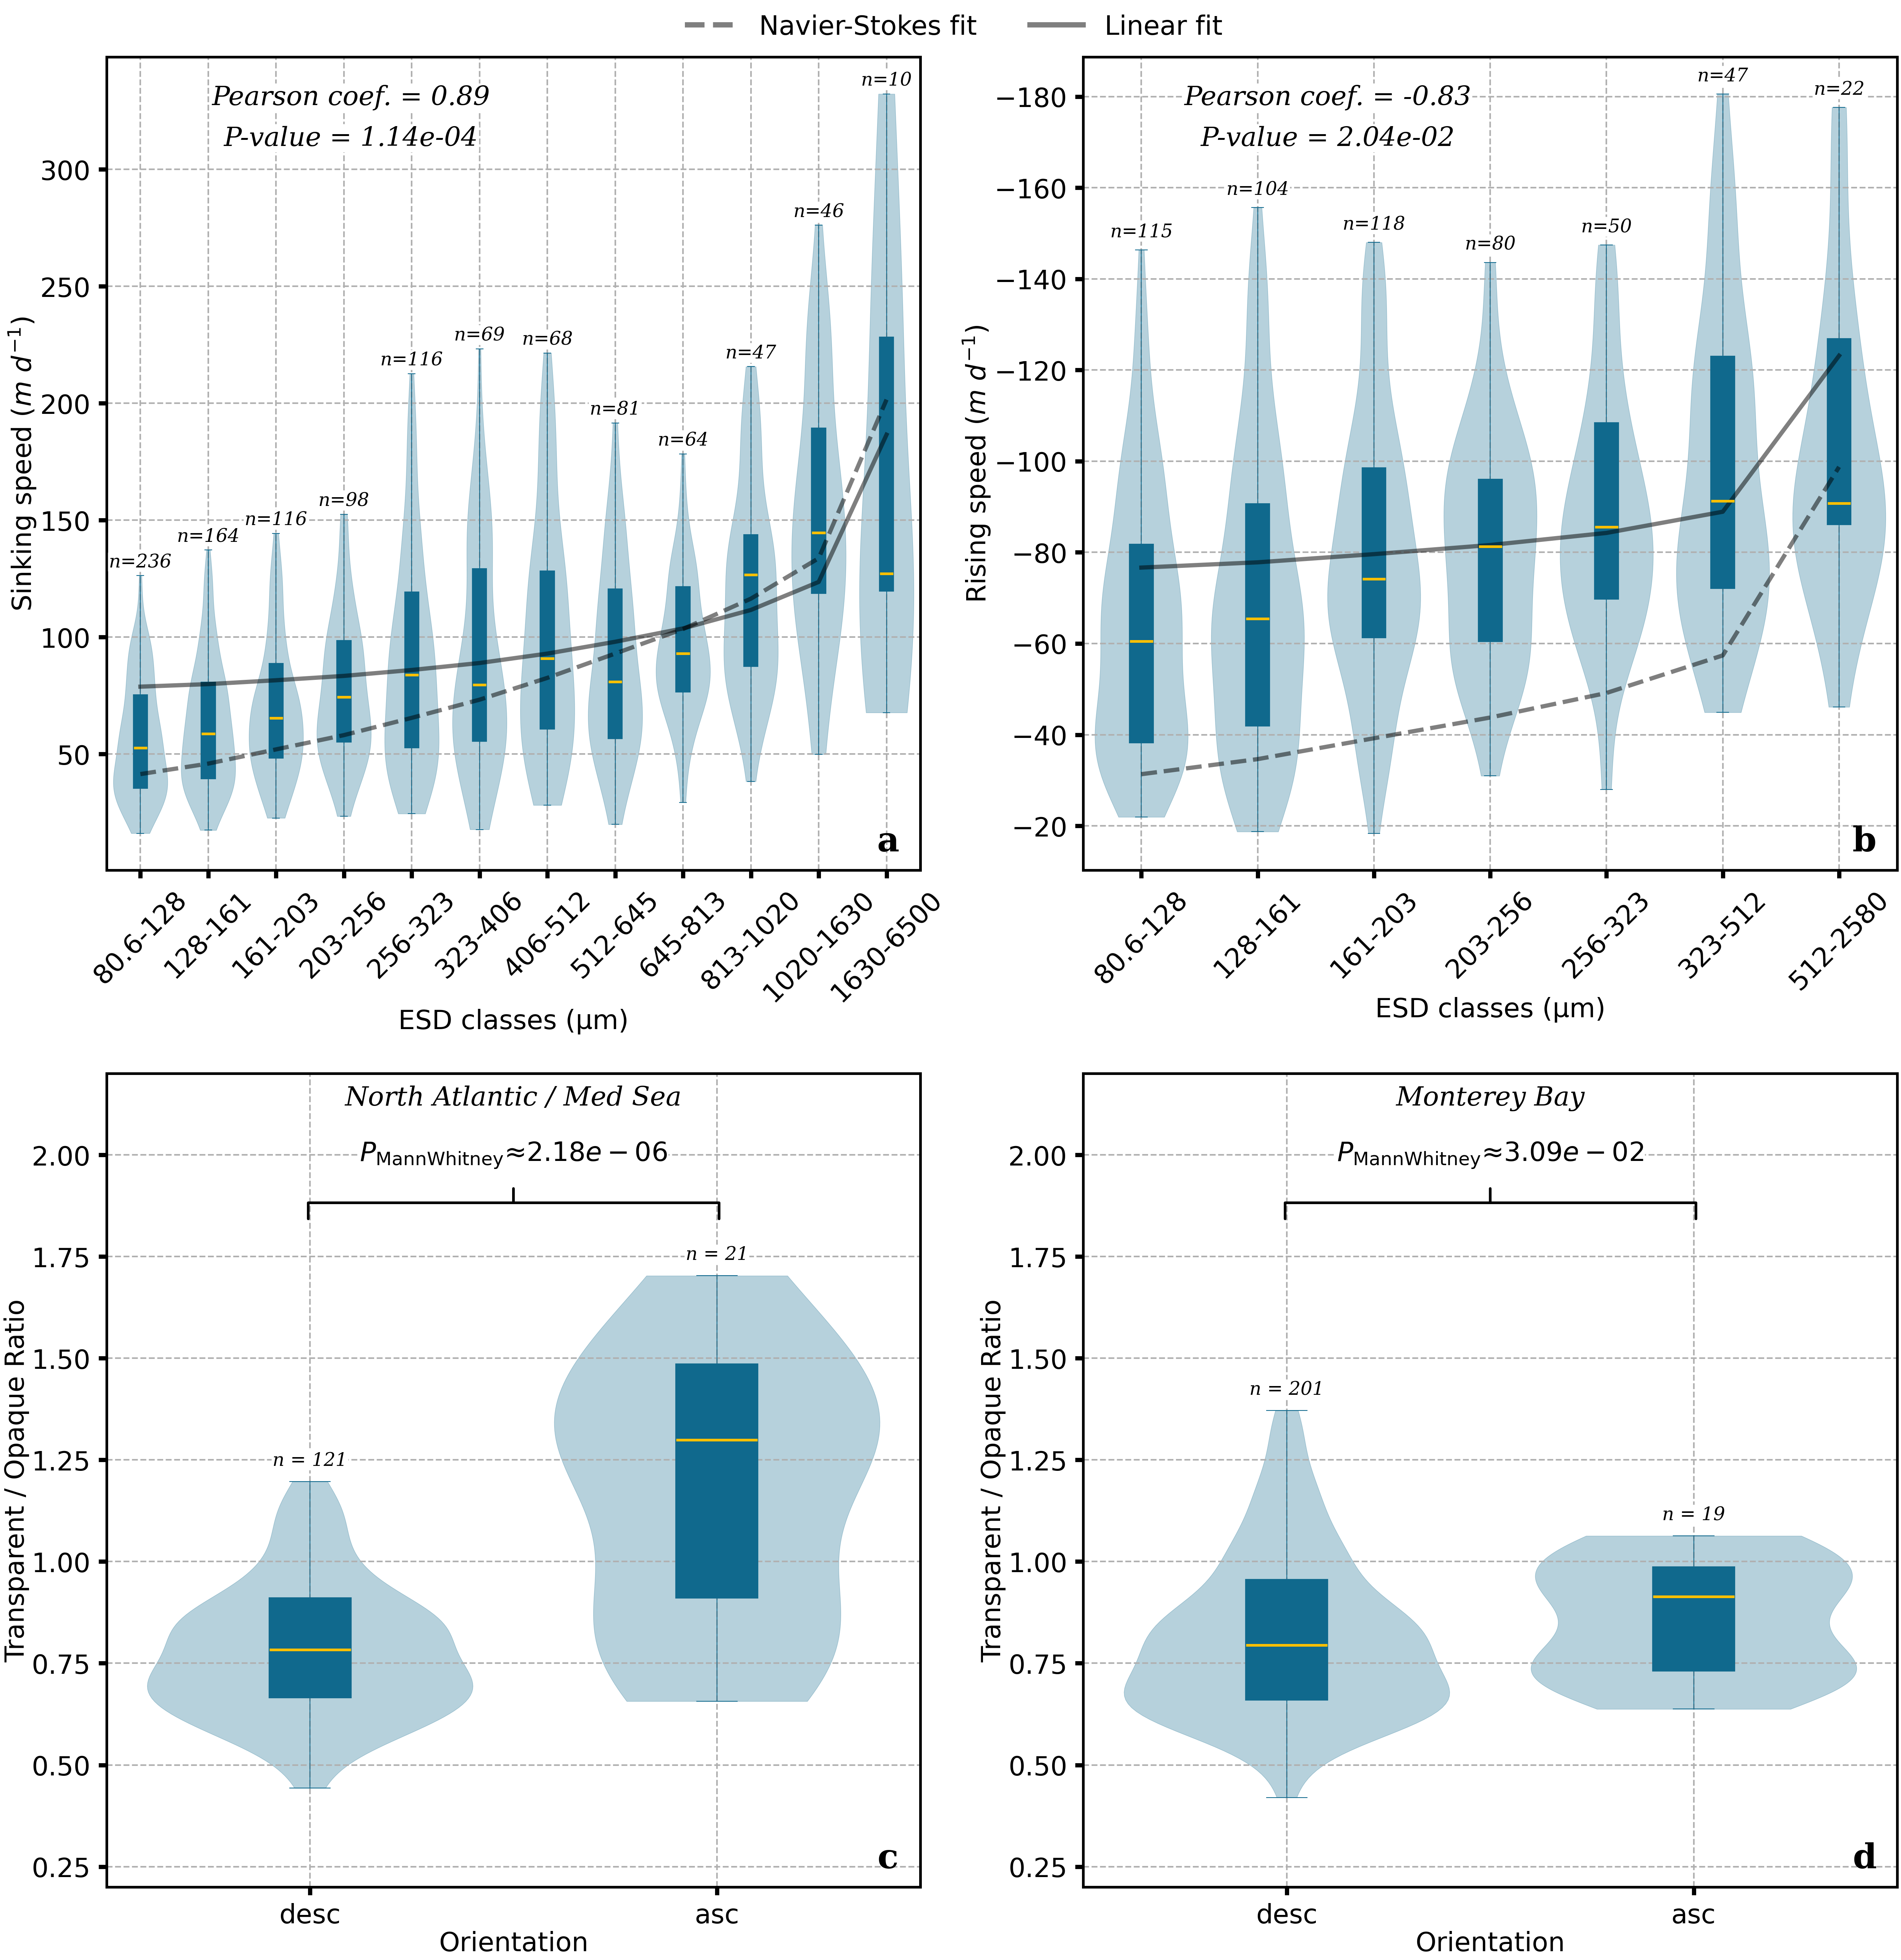

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(50, 50))

boxplot_desc(ax = axs[0, 0], x_col = 'new_size_classes', y_col = 'corrected_by_poly', xlabel = 'ESD classes (µm)', ylabel = 'Sinking speed ($m$ $d^{-1}$)', subplot_indice = 'a', rank = 'esd_um', data = desc)


boxplot_asc(ax=axs[0, 1], x_col = 'new_size_classes', y_col = 'corrected_by_poly', xlabel = 'ESD classes (µm)', ylabel = 'Rising speed ($m$ $d^{-1}$)', subplot_indice = 'b', rank = 'esd_um', data = asc)


# select APERO / VLFR data
APERO_VLFR_df = multi_otu_thresh[multi_otu_thresh['track_id'].str.startswith(('APERO', 'vlfr'))]
boxplot('orientation', 'ratio_low_high', APERO_VLFR_df, xlabel = 'Orientation', ylabel = 'Transparent / Opaque Ratio', subplot_indice = 'c', bracket_width = 12.9, bracket_length = 1, zone = 'North Atlantic / Med Sea', ax = axs[1, 0])


# select MBARI data
MBARI_df = multi_otu_thresh[multi_otu_thresh['track_id'].str.startswith(('MBARI'))]
boxplot('orientation', 'ratio_low_high', MBARI_df, xlabel = 'Orientation', ylabel = 'Transparent / Opaque Ratio', subplot_indice = 'd', bracket_width = 12.9, bracket_length = 1, zone = 'Monterey Bay', ax = axs[1, 1])

# Hide the by default frame
'''
axs = axs.flatten()
for i in [3, 3]:  
    for spine in axs[i].spines.values():
        spine.set_visible(False)
    axs[i].set_facecolor('white')
    axs[i].tick_params(axis='both', which='both', length=0)  # Hides ticks
    axs[i].set_xticklabels([])  # Hides x-axis labels
    axs[i].set_yticklabels([])  # Hides y-axis labels
'''    
# Create custom legend handles
navier_stokes_line = mlines.Line2D([], [], color='black', alpha = 0.5, linestyle= '--', linewidth=10, label='Navier-Stokes fit')
linear_reg_line = mlines.Line2D([], [], color='black', alpha = 0.5, linestyle='-', linewidth=10, label='Linear fit')

# Add the legend for the whole figure
fig.legend(handles=[navier_stokes_line, linear_reg_line], fontsize=50, frameon = False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.025), borderaxespad=0)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.25)

plt.savefig(f'/home/aaccardo/these_alex/Papers/Rising_stars/Figure_5/Figure_5.png', dpi = 300, transparent=False, bbox_inches='tight', pad_inches=0.2 )

plt.show()